# check  cdr RMSD 

### 각 pdb별 샘플들의 h3 cdr RMSD 분포 체크

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


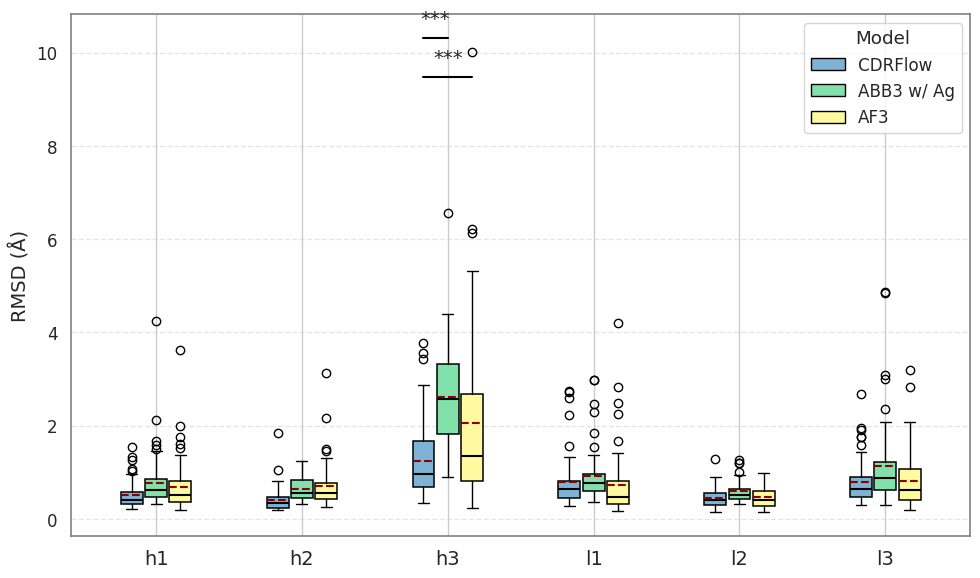

In [10]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import seaborn as sns
from Bio.PDB import PDBParser
from scipy.stats import wilcoxon
from matplotlib.patches import Patch

def calculate_b_factor_mean(pdb_dir, start_residue=95, end_residue=102):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    # 디렉터리 내의 모든 PDB 파일 순회
    for sample in os.listdir(pdb_dir):
        pdb_file = os.path.join(pdb_dir, sample, 'sample_1.pdb')
        pdb_paths.append(pdb_file)
        pdb_path = os.path.join(pdb_dir, pdb_file)
        structure = parser.get_structure("structure", pdb_path)
        
        # 첫 번째 체인 추출
        first_chain = next(iter(structure[0].get_chains()))
        b_factors = []
        for residue in first_chain:
            residue_id = residue.get_id()
            if residue_id[0] == " ":  # 표준 아미노산만 고려
                residue_number = residue_id[1]
                if start_residue <= residue_number <= end_residue:
                    for atom in residue:
                        b_factors.append(atom.get_bfactor())
                
        b_factors_avg.append(np.mean(b_factors))
        max_index = int(np.argmax(b_factors_avg))
    return max_index


pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/WT'
prev_project_dir = '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr'
af3_dir = '/home/psh/af3_output_processed'

rmsd_by_pdb = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
h3_rmsd_by_pdb_prev = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
h3_rmsd_by_pdb_af3 = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
keys = ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']

# RMSD 데이터 수집
for i, pdb_id in enumerate(os.listdir(pred_dir)):
    print(i)
    if 'config' in pdb_id:
        continue
    
    # 이전 프로젝트 RMSD
    prev_filepath = os.path.join(prev_project_dir, pdb_id + '.json')
    if os.path.exists(prev_filepath):
        with open(prev_filepath, 'r') as f:
            prev_data = json.load(f)
        for key in keys:
            h3_rmsd_by_pdb_prev[key].append(prev_data[f'{key}_rms'])
    else:
        continue

    # AF3 RMSD
    sub_dir = os.path.join(af3_dir, pdb_id)
    max_index = calculate_b_factor_mean(sub_dir)
    sample_rmsds = []
    samples_list = os.listdir(sub_dir)
    sample = samples_list[max_index]
    cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
    with open(cdr_info, 'r') as f:
        data = json.load(f)
    for key in keys:
        h3_rmsd_by_pdb_af3[key].append(data[f'{key}_rms'])

    # 현재 프로젝트 RMSD
    sub_dir = os.path.join(pred_dir, pdb_id)
    sample_rmsds = []
    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        sample_rmsds.append({key: data[f'{key}_rms'] for key in keys})

    # h3 기준 정렬 후 10번째 샘플 선택
    if len(sample_rmsds) >= 10:
        sorted_samples = sorted(sample_rmsds, key=lambda x: x['h3'])
        best_sample = sorted_samples[19]
    else:
        best_sample = sorted(sample_rmsds, key=lambda x: x['h3'])[0]

    for key in keys:
        rmsd_by_pdb[key].append(best_sample[key])

# --- Wilcoxon signed-rank test for h3 ---
cdr = 'h3'
cdrflow_vals = rmsd_by_pdb[cdr]
abb3_vals = h3_rmsd_by_pdb_prev[cdr]
af3_vals = h3_rmsd_by_pdb_af3[cdr]

stat1, p_val1 = wilcoxon(cdrflow_vals, abb3_vals)
stat2, p_val2 = wilcoxon(cdrflow_vals, af3_vals)

def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

star1 = get_star(p_val1)
star2 = get_star(p_val2)

# --- Boxplot 그리기 (6 CDR) ---
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['axes.edgecolor'] = 'gray'
plt.rcParams['axes.linewidth'] = 1.2

model_names = ['CDRFlow','ABB3 w/ Ag', 'AF3']
colors = ['#7FB3D5', '#82E0AA', "#FFF99F"]
cdrs = ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']

data_to_plot = []
positions = []
width = 0.6
gap = 1.2
group_width = 0.2

for i, cdr in enumerate(cdrs):
    values = [
        rmsd_by_pdb[cdr],
        h3_rmsd_by_pdb_prev[cdr],
        h3_rmsd_by_pdb_af3[cdr]
    ]
    for j, val in enumerate(values):
        pos = i * gap + j * group_width
        positions.append(pos)
        data_to_plot.append(val)

plt.figure(figsize=(10,6))
box = plt.boxplot(data_to_plot, positions=positions, widths=group_width*0.9, patch_artist=True, showmeans=True, meanline=True)

# 색상 적용
for patch, i in zip(box['boxes'], range(len(data_to_plot))):
    patch.set_facecolor(colors[i % 3])
    patch.set_edgecolor('black')
    patch.set_linewidth(1.1)

for median in box['medians']:
    median.set(color='black', linewidth=1.5)
for mean in box['means']:
    mean.set(color='darkred', linewidth=1.5)

# X축 레이블
group_centers = [i * gap + group_width for i in range(len(cdrs))]
plt.xticks(group_centers, cdrs, fontsize=14)
plt.ylabel('RMSD (Å)', fontsize=14)

# --- h3 CDR에만 별 표시 ---
h3_idx = cdrs.index('h3')
x_cdrflow = h3_idx * gap + 0 * group_width
x_abb3 = h3_idx * gap + 1 * group_width
x_af3 = h3_idx * gap + 2 * group_width
y_max = max(max(cdrflow_vals), max(abb3_vals), max(af3_vals)) * 1.05

# CDRFlow vs ABB3
plt.plot([x_cdrflow, x_abb3],[y_max*0.98, y_max*0.98], color='black', lw=1.5)
plt.text((x_cdrflow+x_abb3)/2, y_max*1.0, star1, ha='center', va='bottom', fontsize=14)
# CDRFlow vs AF3
plt.plot([x_cdrflow, x_af3],[y_max*0.9, y_max*0.9], color='black', lw=1.5)
plt.text((x_cdrflow+x_af3)/2, y_max*0.92, star2, ha='center', va='bottom', fontsize=14)

# Legend
legend_handles = [Patch(facecolor=colors[i], edgecolor='black', label=model_names[i]) for i in range(3)]
plt.legend(handles=legend_handles, title='Model', loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 각 pdb에서 상위 10위 추출

In [1]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import os 
import json 

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/benchmark'
h3_rmsd_by_pdb = {}
top_10_rmsd_by_pdb = {}
top_rank = 25

pdb_ids = []
for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  


for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    sorted_rmsd = sorted(rmsd_list, reverse=False)  # 내림차순 정렬
    top_10_rmsd_by_pdb[pdb] = sorted_rmsd[top_rank-1]  # 상위 10개 선택

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_10_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

1.4986312542943996


### confidence metric과 h3 rmsd 간의 correlation 

In [ ]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser
from scipy.stats import spearmanr
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed

# CDR 위치 (Chothia 번호)
cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_path, start_residue, end_residue):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("structure", pdb_path)
    first_chain = next(iter(structure[0].get_chains()))
    b_factors = []

    for residue in first_chain:
        residue_id = residue.get_id()
        if residue_id[0] == " ":
            residue_number = residue_id[1]
            if start_residue <= residue_number <= end_residue:
                for atom in residue:
                    b_factors.append(atom.get_bfactor())

    if len(b_factors) == 0:
        return np.nan
    return np.mean(b_factors)

def process_pdb(pdb_dir):
    pdb_key = pdb_dir.split('_')[0]
    print(pdb_key)
    sub_dir = os.path.join(pred_dir, pdb_dir)
    records = []

    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue

        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        pdb_path = os.path.join(sub_dir, sample, "sample_1.pdb")
        try:
            with open(cdr_info, 'r') as f:
                data = json.load(f)
        except:
            continue

        record = {
            'pdb_id': pdb_key,
            'sample_id': sample,
            'h3_rmsd': data['h3_rms']
        }

        for cdr, (start, end) in cdr_chothia.items():
            record[f'{cdr}_b_factor_mean'] = calculate_b_factor_mean(pdb_path, start, end)

        records.append(record)
    return records

# 경로
pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/benchmark'

# PDB 리스트
pdb_dirs = [d for d in os.listdir(pred_dir) if 'config' not in d]

all_records = []

# 병렬 처리
with ProcessPoolExecutor(max_workers=60) as executor:
    futures = [executor.submit(process_pdb, pdb_dir) for pdb_dir in pdb_dirs]
    for future in as_completed(futures):
        records = future.result()
        all_records.extend(records)

# DataFrame 생성 및 CSV 저장
df = pd.DataFrame(all_records)
df.to_csv('cdr_bfactor_h3_rmsd_samples.csv', index=False)
print("✅ CSV saved as 'cdr_bfactor_h3_rmsd_samples.csv'")

# top 1 B-factor 기준으로 PDB별 scatter plot 생성
df_top = df

features = [f'{cdr}_b_factor_mean' for cdr in cdr_chothia.keys()]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    spearman_corr, _ = spearmanr(df_top[feature], df_top['h3_rmsd'])
    axes[i].scatter(df_top[feature], df_top['h3_rmsd'], alpha=0.6)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('h3_rmsd')
    axes[i].set_title(f'{feature} vs h3_rmsd\nSpearman r={spearman_corr:.3f}')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('cdr_bfactor_vs_h3_rmsd_top1.png', dpi=300)
plt.close()
print("✅ Scatter plot figure saved as 'cdr_bfactor_vs_h3_rmsd_top1.png'")


### 6 cdr plddt를 적절히 combination해서 설명력 좋은 metric으로 만들기 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from scipy.optimize import differential_evolution
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing
import os

# =======================
# 1️⃣ 데이터 로드 및 준비
# =======================
input_csv = '/home/psh/cdr_bfactor_h3_rmsd_samples.csv'
output_metric_csv = '/home/psh/cdr_plddt_metric_with_pdb_corr.csv'
output_weight_csv = '/home/psh/plddt_feature_weights.csv'

df = pd.read_csv(input_csv)

features = [f'{cdr}_plddt' for cdr in ['h1','h2','h3','l1','l2','l3']]
target = 'h3_rmsd'

df = df.dropna(subset=features + [target])
print(f"✅ 유효 샘플 수: {len(df)}")

# 스케일링
scaler = StandardScaler()
X = scaler.fit_transform(df[features].values)
y = df[target].values

# =======================
# 2️⃣ 하위 RMSD 강조 (가중 목적)
# =======================
threshold = np.percentile(y, 25)
low_mask = y <= threshold

# =======================
# 3️⃣ 목적 함수 정의
# =======================
def metric_score(weights):
    metric = X.dot(weights)
    corr_full, _ = spearmanr(metric, y)
    corr_low, _ = spearmanr(metric[low_mask], y[low_mask])
    # 낮은 RMSD(좋은 샘플)에 더 높은 가중치
    score = 0.7 * corr_low + 0.3 * corr_full
    return -score  # maximize → minimize(-score)

# =======================
# 4️⃣ Differential Evolution 최적화
# =======================
bounds = [(-2, 2)] * len(features)
result = differential_evolution(
    metric_score,
    bounds,
    maxiter=300,
    popsize=30,
    tol=1e-6,
    polish=True,
    seed=42,
    updating="deferred",  # 병렬 최적화
    workers=-1             # 모든 CPU 코어 사용
)

opt_weights = result.x / np.linalg.norm(result.x)
df['metric'] = X.dot(opt_weights)

# =======================
# 5️⃣ 전체 / 하위 25% 상관관계 평가
# =======================
corr_full, _ = spearmanr(df['metric'], y)
corr_low, _ = spearmanr(df.loc[low_mask, 'metric'], df.loc[low_mask, target])

print("\n✅ 최적화 완료!")
for f, w in zip(features, opt_weights):
    print(f"{f:<20} {w:+.3f}")
print(f"\n📈 전체 Spearman: {corr_full:.3f}")
print(f"🎯 하위 25% Spearman: {corr_low:.3f}")

# =======================
# 6️⃣ 각 PDB별 Spearman 계산 (병렬)
# =======================
def compute_pdb_corr(pdb_id, sub_df):
    """개별 pdb의 Spearman 계산 함수"""
    if len(sub_df) < 3:
        return pdb_id, np.nan
    corr, _ = spearmanr(sub_df['metric'], sub_df[target])
    return pdb_id, corr

pdb_groups = list(df.groupby('pdb_id'))

print(f"⚙️ {len(pdb_groups)}개 PDB에 대해 Spearman 계산 중... (multi-CPU)")

spearman_results = []
with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
    futures = {executor.submit(compute_pdb_corr, pdb, sub): pdb for pdb, sub in pdb_groups}
    for future in as_completed(futures):
        pdb_id, corr = future.result()
        spearman_results.append((pdb_id, corr))

spearman_df = pd.DataFrame(spearman_results, columns=['pdb_id', 'pdb_spearman'])
df_with_corr = df.merge(spearman_df, on='pdb_id', how='left')

# =======================
# 7️⃣ 결과 저장
# =======================
df_with_corr.to_csv(output_metric_csv, index=False)
print(f"💾 Spearman 결과 저장: {output_metric_csv}")

weight_df = pd.DataFrame({
    'feature': features,
    'weight': opt_weights
})
weight_df.to_csv(output_weight_csv, index=False)
print(f"💾 가중치 저장: {output_weight_csv}")

print("\n✅ 모든 작업 완료!")


✅ 유효 샘플 수: 5900


KeyboardInterrupt: 

## 각 pdb에서 confidence 기반 Top N 뽑기 

In [2]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import os 
import json 
from Bio.PDB import PDBParser

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_path, start_residue=95, end_residue=102):

    parser = PDBParser(QUIET=True)


    structure = parser.get_structure("structure", pdb_path)
    
    # 첫 번째 체인 추출
    first_chain = next(iter(structure[0].get_chains()))
    b_factors = []
    for residue in first_chain:
        residue_id = residue.get_id()
        if residue_id[0] == " ":  # 표준 아미노산만 고려
            residue_number = residue_id[1]
            if start_residue <= residue_number <= end_residue:
                for atom in residue:
                    b_factors.append(atom.get_bfactor())
            
    b_factors_avg = np.mean(b_factors)

    return b_factors_avg

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_only_plddt/2025-11-09_00-08-56/epoch=27-step=40124/run_2025-11-10_19-36-04'
h3_rmsd_by_pdb = {}
b_factors_by_pdb = {}
top_n_rmsd_by_pdb = {}
top_rank = 1

pdb_ids = []
for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    h3_b_factors = []
    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        pdb_path = os.path.join(sub_dir, sample, "sample_1.pdb")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
        h3_b_factors.append(calculate_b_factor_mean(pdb_path))

    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  
    b_factors_by_pdb[pdb_key] = h3_b_factors

for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    b_factors = b_factors_by_pdb[pdb]
    top_n_b_factor = sorted(b_factors, reverse=True)[top_rank-1]
    top_n_index = b_factors.index(top_n_b_factor)
    top_n_rmsd_by_pdb[pdb] = rmsd_list[top_n_index] 

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_n_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

FileNotFoundError: [Errno 2] No such file or directory: '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_only_plddt/2025-11-09_00-08-56/epoch=27-step=40124/run_2025-11-10_19-36-04/7tzh_C_Z_D.pkl/sample_93/cdr_rmsd.json'

### 각 모델 별 rmsd 비교 

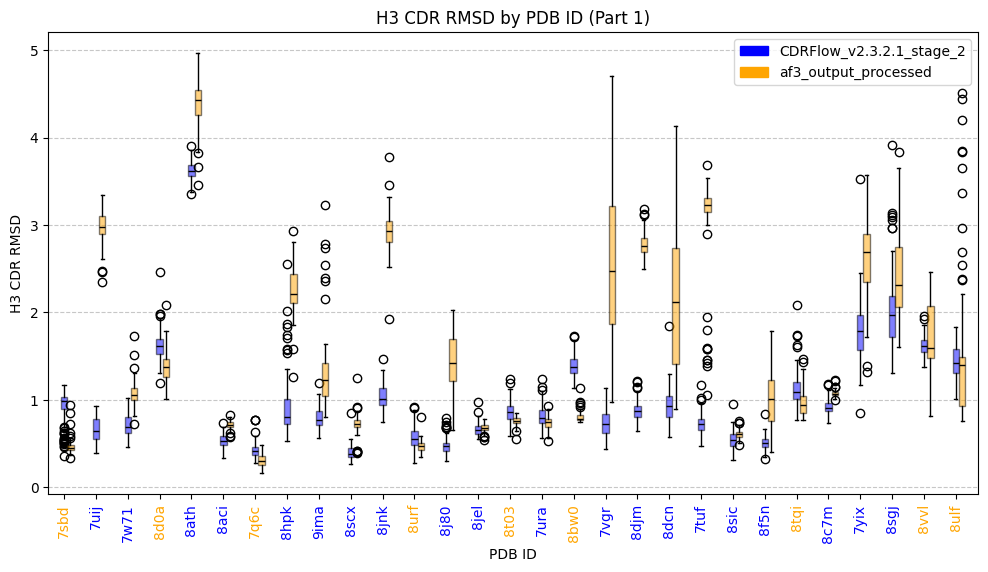

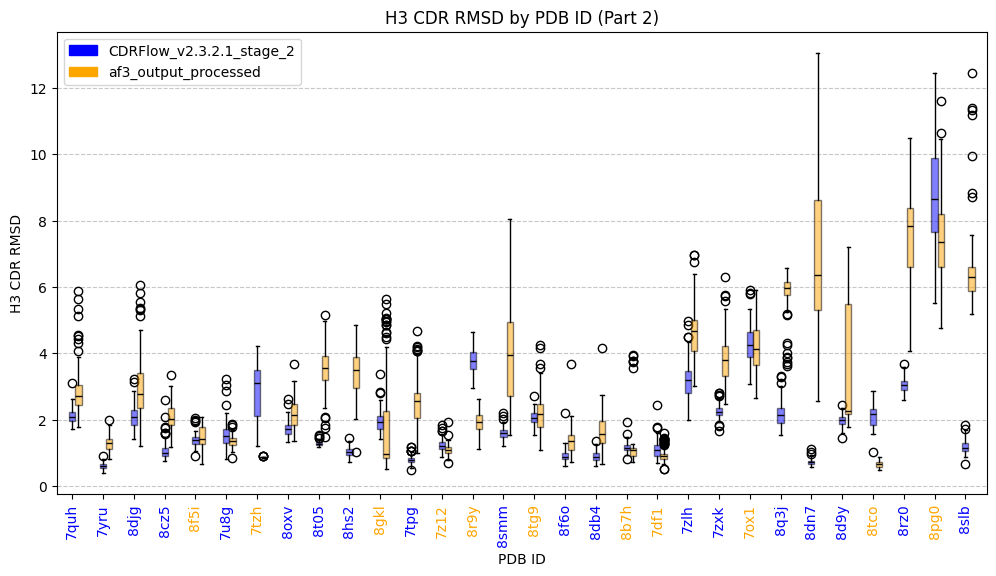

In [ ]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind

pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/WT',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

# PDB ID 수집
all_pdb_ids = set()

for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue  # 설정 파일은 건너뜀

        pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
        all_pdb_ids.add(pdb_key)

        # 현재 프로젝트에서 RMSD 값 불러오기
        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        for sample in os.listdir(sub_dir):
            if 'sample' not in sample:
                continue
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            with open(cdr_info, 'r') as f:
                data = json.load(f)
            h3_cdrs.append(data['h3_rms'])

        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs  

# h3 length 길이 순으로 pdb name 정렬 
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df_sorted = df.sort_values(by="h3_diff", ascending=True)
sorted_pdb_ids = df_sorted["pdb_name"].tolist()
sorted_pdb_ids = [filename.split('_')[0] for filename in sorted_pdb_ids if filename.split('_')[0] in all_pdb_ids]

# PDB ID를 3등분
num_splits = 2
split_size = len(sorted_pdb_ids) // num_splits
split_pdb_ids = [sorted_pdb_ids[i * split_size:(i + 1) * split_size] for i in range(num_splits - 1)]
split_pdb_ids.append(sorted_pdb_ids[(num_splits - 1) * split_size:])  # 마지막 부분 추가

# 색상 설정
colors = ['blue', 'orange']
handles = [
    mpatches.Patch(
        color=colors[idx],
        label=dir.split('/')[5] if len(dir.split('/')) > 5 else dir.split('/')[3]
    )
    for idx, dir in enumerate(pred_dirs)
]

# 📌 그래프 그리기 (3개로 분할)
# 📌 그래프 그리기 (2개로 분할)
for i, pdb_subset in enumerate(split_pdb_ids):
    plt.figure(figsize=(12, 6))

    tenth_values = {pred_dirs[0]: [], pred_dirs[1]: []}

    for idx, pred_dir in enumerate(pred_dirs):
        h3_rmsd_sorted = [h3_rmsd_by_pdb[pred_dir].get(pdb, []) for pdb in pdb_subset]

        # 박스플롯 그리기
        boxplot = plt.boxplot(h3_rmsd_sorted, positions=np.arange(len(pdb_subset)) + (idx * 0.2), widths=0.2,
                              patch_artist=True, boxprops=dict(facecolor=colors[idx], alpha=0.5),
                              medianprops=dict(color='black'))

        # 각 PDB에 대해 낮은 것부터 10번째 값을 저장
        for rmsd_list in h3_rmsd_sorted:
            sorted_rmsd = sorted(rmsd_list)
            if len(sorted_rmsd) >= 10:
                tenth_value = sorted_rmsd[9]  # 인덱스는 0부터 시작하므로 10번째 값은 인덱스 9
            else:
                tenth_value = None  # 또는 np.nan
            tenth_values[pred_dir].append(tenth_value)

    # 중앙값 비교 후 색상 결정
    xlabel_colors = []
    for j, pdb in enumerate(pdb_subset):
        if tenth_values[pred_dirs[0]][j] < tenth_values[pred_dirs[1]][j]:
            xlabel_colors.append(colors[0])  # 첫 번째 모델 색상
        else:
            xlabel_colors.append(colors[1])  # 두 번째 모델 색상

    # 📌 PDB ID의 색상 
    plt.xticks(range(len(pdb_subset)), pdb_subset, rotation=90)  # color 제거

    # 📌 x축 레이블 개별적으로 색상 설정
    ax = plt.gca()  # 현재 축 가져오기
    for label, color in zip(ax.get_xticklabels(), xlabel_colors):
        label.set_color(color)


    # 그래프 설정
    plt.xlabel("PDB ID")
    plt.ylabel("H3 CDR RMSD")
    plt.title(f"H3 CDR RMSD by PDB ID (Part {i+1})")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(handles=handles)

    # 그래프 표시
    plt.show()



# check self-confidence correlation 

## by sample 

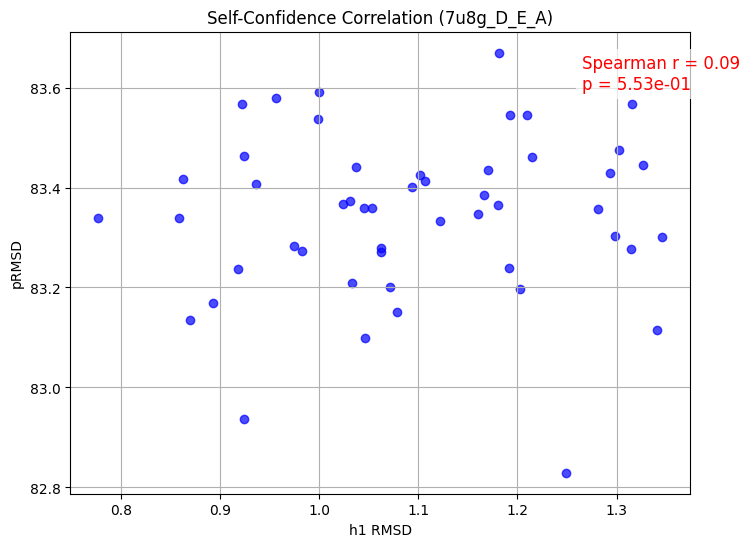

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import PDBParser

from scipy.stats import spearmanr

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_dir, cdr_type):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    start_residue = cdr_chothia[cdr_type][0]
    end_residue = cdr_chothia[cdr_type][1]
    # 디렉터리 내의 모든 PDB 파일 순회
    for sample in sorted(os.listdir(pdb_dir)):
        pdb_file = os.path.join(pdb_dir, sample, 'sample_1.pdb')
        pdb_paths.append(pdb_file)
        pdb_path = os.path.join(pdb_dir, pdb_file)
        structure = parser.get_structure("structure", pdb_path)
        
        # 첫 번째 체인 추출
        first_chain = next(iter(structure[0].get_chains()))
        b_factors = []
        for residue in first_chain:
            residue_id = residue.get_id()
            if residue_id[0] == " ":  # 표준 아미노산만 고려
                residue_number = residue_id[1]
                if start_residue <= residue_number <= end_residue:
                    # 각 원자의 B-factor 가져오기
                    for atom in residue:
                        b_factors.append(atom.get_bfactor())

        b_factors_avg.append(np.mean(b_factors))
        
    return b_factors_avg, pdb_paths

# PDB 디렉터리 설정
cdr_type = "h1"
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-10-29_12-41-30/7u8g_D_E_A'
pdb_id = pdb_dir.split('/')[-1]
b_factors, pdb_paths = calculate_b_factor_mean(pdb_dir, cdr_type=cdr_type)

# RMSD 값 수집

cdr_rmsd_dir = pdb_dir
rmsd_values = []

json_paths = []
for sample in sorted(os.listdir(cdr_rmsd_dir)):

    json_file = os.path.join(cdr_rmsd_dir, sample, 'cdr_rmsd.json')
    json_paths.append(json_file)
    # JSON 파일에서 RMSD 데이터 읽기
    with open(json_file, 'r') as f:
        rmsd_data = json.load(f)

    cdr_rmsd = rmsd_data.get(f'{cdr_type}_rms', None)  # 'h3_rms' 키에서 RMSD 값 가져옴
    if cdr_rmsd is not None:
        rmsd_values.append(cdr_rmsd)



correlation_coefficient = spearmanr(rmsd_values, b_factors)

# scatter plot 그리기
plt.figure(figsize=(8, 6))
plt.scatter(rmsd_values, b_factors, color='blue', alpha=0.7)
x_pos = np.mean(rmsd_values) + (max(rmsd_values) - min(rmsd_values)) * 0.3
y_pos = np.mean(b_factors) + (max(b_factors) - min(b_factors)) * 0.3
plt.text(x_pos, y_pos,
         f"Spearman r = {correlation_coefficient[0]:.2f}\n"
         f"p = {correlation_coefficient[1]:.2e}",
         fontsize=12, color='red',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# 플롯 세부 설정
plt.title(f"Self-Confidence Correlation ({pdb_id})")
plt.xlabel(f"{cdr_type} RMSD")
plt.ylabel("pLDDT")
plt.grid(True)
plt.show()



## all inference output 

In [32]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import PDBParser

from scipy.stats import spearmanr

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_dir, cdr_type):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    start_residue = cdr_chothia[cdr_type][0]
    end_residue = cdr_chothia[cdr_type][1]
    # 디렉터리 내의 모든 PDB 파일 순회
    for pdb in sorted(os.listdir(pdb_dir)):
        if 'config' in pdb:
            continue 
        
        print(f"{pdb} b_factor")
        pdb_path = os.path.join(pdb_dir, pdb)
        for sample in os.listdir(pdb_path):
            if "sample" not in sample:
                continue


            pdb_file = os.path.join(pdb_path, sample, 'sample_1.pdb')
            pdb_paths.append(pdb_file)
            structure = parser.get_structure("structure", pdb_file)
            
            # 첫 번째 체인 추출
            first_chain = next(iter(structure[0].get_chains()))
            b_factors = []
            for residue in first_chain:
                residue_id = residue.get_id()
                if residue_id[0] == " ":  # 표준 아미노산만 고려
                    residue_number = residue_id[1]
                    if start_residue <= residue_number <= end_residue:
                        # 각 원자의 B-factor 가져오기
                        for atom in residue:
                            b_factors.append(atom.get_bfactor())

            b_factors_avg.append(np.mean(b_factors))
        
    return b_factors_avg, pdb_paths

# PDB 디렉터리 설정
cdr_type = "h3"
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-10-29_12-41-30'
b_factors, pdb_paths = calculate_b_factor_mean(pdb_dir, cdr_type=cdr_type)

# RMSD 값 수집

rmsd_values = []
json_paths = []
for pdb in sorted(os.listdir(pdb_dir)):
    if 'config' in pdb:
        continue 
    print(f"{pdb} rmsd")
    pdb_path = os.path.join(pdb_dir, pdb)
    for sample in os.listdir(pdb_path):
        if "sample" not in sample:
            continue

        json_file = os.path.join(pdb_path, sample, 'cdr_rmsd.json')
        json_paths.append(json_file)
        # JSON 파일에서 RMSD 데이터 읽기
        with open(json_file, 'r') as f:
            rmsd_data = json.load(f)

        cdr_rmsd = rmsd_data.get(f'{cdr_type}_rms', None)  # 'h3_rms' 키에서 RMSD 값 가져옴
        if cdr_rmsd is not None:
            rmsd_values.append(cdr_rmsd)


correlation_coefficient = spearmanr(rmsd_values, b_factors)

# scatter plot 그리기
plt.figure(figsize=(8, 6))
plt.scatter(rmsd_values, b_factors, color='blue', alpha=0.5)
x_pos = np.mean(rmsd_values) + (max(rmsd_values) - min(rmsd_values)) * 0.3
y_pos = np.mean(b_factors) + (max(b_factors) - min(b_factors)) * 0.3
plt.text(x_pos, y_pos,
         f"Spearman r = {correlation_coefficient[0]:.2f}\n"
         f"p = {correlation_coefficient[1]:.2e}",
         fontsize=12, color='red',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# 플롯 세부 설정
plt.title(f"Self-Confidence Correlation ({pdb_id})")
plt.xlabel(f"{cdr_type} RMSD")
plt.ylabel("pLDDT")
plt.grid(True)
plt.show()



7df1_F_J_C b_factor
7ox1_A_B_G b_factor
7q6c_H_L_A b_factor
7quh_H_L_A b_factor
7sbd_H_L_C b_factor
7tpg_H_L_B b_factor
7tuf_A_B_C b_factor
7tzh_C_Z_D b_factor
7u8g_D_E_A b_factor
7uij_H_L_CD b_factor
7ura_H_L_A b_factor
7vgr_D_C_AB b_factor
7w71_I_M_B b_factor
7yix_D_Z_AB b_factor
7yru_H_L_A b_factor
7z12_B_C_A b_factor
7zlh_H_L_A b_factor
7zxk_J_I_AB b_factor
8aci_H_L_A b_factor
8ath_E_F_B b_factor
8b7h_H_L_AB b_factor
8bw0_H_L_C b_factor
8c7m_C_D_B b_factor
8cz5_H_L_A b_factor
8d0a_H_L_A b_factor
8d9y_B_A_I b_factor
8db4_A_B_E b_factor
8dcn_D_E_F b_factor
8djg_C_D_E b_factor
8djm_H_L_BA b_factor
8dn7_D_H_E b_factor
8f5i_X_Y_A b_factor
8f5n_H_L_A b_factor
8f6o_A_B_C b_factor
8gkl_H_L_E b_factor
8hpk_H_L_A b_factor
8hs2_B_C_R b_factor
8j80_E_C_AB b_factor
8jel_C_D_J b_factor
8jnk_I_M_A b_factor
8oxv_B_C_A b_factor
8pg0_H_L_A b_factor
8q3j_C_B_A b_factor
8r9y_B_C_A b_factor
8rz0_F_Z_E b_factor
8scx_H_L_ABC b_factor
8sgj_H_L_A b_factor
8sic_A_B_E b_factor
8slb_H_L_A b_factor
8smm_H_L_A 

FileNotFoundError: [Errno 2] No such file or directory: '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-10-29_12-41-30/8smm_H_L_A/sample_19/sample_1.pdb'

# CDF 형태의 plot

config.yaml
7df1_F_J_C
7ox1_A_B_G
7q6c_H_L_A
7quh_H_L_A
7sbd_H_L_C
7tpg_H_L_B
7tuf_A_B_C
7tzh_C_Z_D
7u8g_D_E_A
7uij_H_L_CD
7ura_H_L_A
7vgr_D_C_AB
7w71_I_M_B
7yix_D_Z_AB
7yru_H_L_A
7z12_B_C_A
7zlh_H_L_A
7zxk_J_I_AB
8aci_H_L_A
8ath_E_F_B
8b7h_H_L_AB
8bw0_H_L_C
8c7m_C_D_B
8cz5_H_L_A
8d0a_H_L_A
8d9y_B_A_I
8db4_A_B_E
8dcn_D_E_F
8djg_C_D_E
8djm_H_L_BA
8dn7_D_H_E
8f5i_X_Y_A
8f5n_H_L_A
8f6o_A_B_C
8gkl_H_L_E
8hpk_H_L_A
8hs2_B_C_R
8j80_E_C_AB
8jel_C_D_J
8jnk_I_M_A
8oxv_B_C_A
8pg0_H_L_A
8q3j_C_B_A
8r9y_B_C_A
8rz0_F_Z_E
8scx_H_L_ABC
8sgj_H_L_A
8sic_A_B_E
8slb_H_L_A
8smm_H_L_A
8t03_C_D_AB
8t05_C_D_AB
8tco_F_G_ABC
8tg9_E_F_B
8tqi_H_L_AB
8ulf_H_L_AB
8urf_H_L_A
8vvl_H_L_A
9ima_C_D_AB


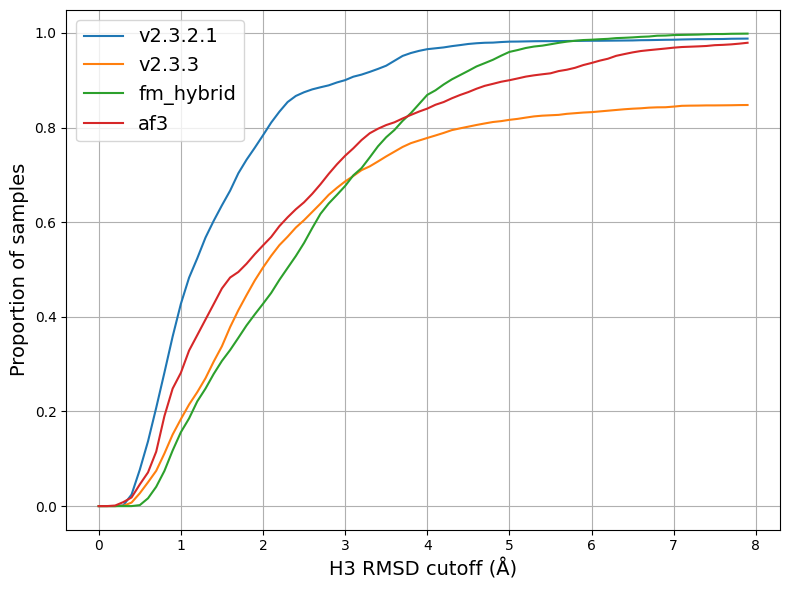

In [2]:
pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/run_2025-10-15_16-05-43'
af3_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.3_stage_2/2025-10-14_00-45-15/epoch=23-step=34392/run_2025-10-15_10-59-20'
pred_dir_wo_atom = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37'
pred_new_dir = '/home/psh/af3_output_processed/'
import os 
import json 

pred_cdrs = []
pred_wo_atom = []
af3_cdrs = []
pred_new_cdrs = []
for pdb in os.listdir(pred_dir):
    print(pdb)
    if 'config' in pdb:
        continue
    af3_pdb = os.path.join(af3_dir, pdb)
    pred_pdb = os.path.join(pred_dir, pdb)
    pred_wo_atom_pdb = os.path.join(pred_dir_wo_atom, pdb)
    pred_new_pdb = os.path.join(pred_new_dir, pdb)
    for sample in os.listdir(pred_pdb):
        if 'sample' not in sample:
            continue
        pred_cdr_json = os.path.join(pred_pdb, sample, "cdr_rmsd.json")
        af3_cdr_json = os.path.join(af3_pdb, sample, "cdr_rmsd.json")
        pred_wo_atom_json = os.path.join(pred_wo_atom_pdb, sample, "cdr_rmsd.json")
        pred_new_json = os.path.join(pred_new_pdb, sample, "cdr_rmsd.json")

        with open(pred_cdr_json, 'r') as f:
            pred_cdr_data = json.load(f)
        pred_cdrs.append(pred_cdr_data['h3_rms'])

        with open(af3_cdr_json, 'r') as f:
            af3_cdr_data = json.load(f)
        af3_cdrs.append(af3_cdr_data['h3_rms'])

        with open(pred_wo_atom_json, 'r') as f:
            pred_wo_atom_cdr_data = json.load(f)
        pred_wo_atom.append(pred_wo_atom_cdr_data['h3_rms'])

        with open(pred_new_json, 'r') as f:
            pred_new_cdr_data = json.load(f)
        pred_new_cdrs.append(pred_new_cdr_data['h3_rms'])
import matplotlib.pyplot as plt
import numpy as np

# numpy array로 변환
pred_cdrs = np.array(pred_cdrs)
af3_cdrs = np.array(af3_cdrs)
pred_wo_atom_cdrs = np.array(pred_wo_atom)
pred_new_cdrs = np.array(pred_new_cdrs) 

# cutoff 범위 설정 (0부터 5까지 0.1 간격)
cutoffs = np.arange(0, 8, 0.1)

# 각 cutoff 이하인 비율 계산
pred_cdf = [(pred_cdrs <= c).sum() / len(pred_cdrs) for c in cutoffs]
af3_cdf = [(af3_cdrs <= c).sum() / len(af3_cdrs) for c in cutoffs]
pred_wo_atom_cdf = [(pred_wo_atom_cdrs <= c).sum() / len(pred_wo_atom_cdrs) for c in cutoffs]
pred_new_cdrs_cdf = [(pred_new_cdrs <= c).sum() / len(pred_new_cdrs) for c in cutoffs]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(cutoffs, pred_cdf, label='v2.3.2.1')
plt.plot(cutoffs, af3_cdf, label='v2.3.3')
plt.plot(cutoffs, pred_wo_atom_cdf, label='fm_hybrid')
plt.plot(cutoffs, pred_new_cdrs_cdf, label='af3')
# plt.plot(cutoffs, pred_wo_ag, label='CDRFlow w/o Ag')
plt.xlabel('H3 RMSD cutoff (Å)', fontsize=14)
plt.ylabel('Proportion of samples', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


# scatter plot (AF3 vs CDRFlow) by DockQ score 

/tmp/ipykernel_496668/2184707424.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 4)


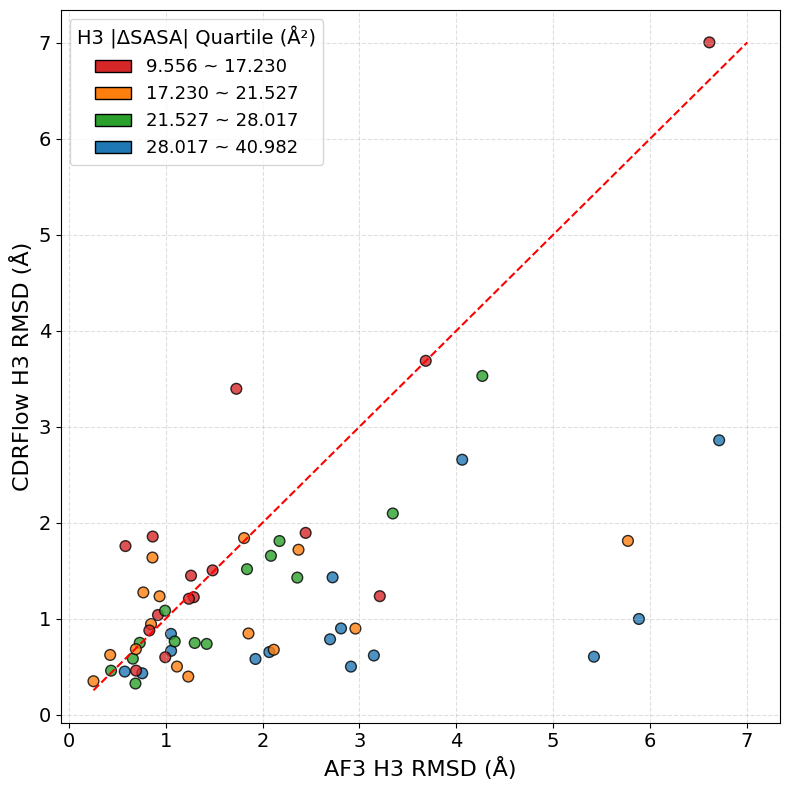

In [2]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/WT',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
dockq_by_pdb_indexed = {}
all_pdb_ids = set()

energy_dir = '/home/psh/benchmark_after210930/interface_energy'
h3_sasa = {}

for file in os.listdir(energy_dir):
    # collect h3 average delta sasa 
    energy_json = os.path.join(energy_dir, file)
    with open(energy_json, 'r') as f:
        energy_data = json.load(f)

    pdb_id = file.replace('.json', '').split('_')[0]
    h3_sasa[pdb_id] = energy_data['h3_sasa_avg']

# RMSD 및 DockQ 수집
for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue

        pdb_key = pdb_id.split('_')[0]
        all_pdb_ids.add(pdb_key)

        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        dockqs = []

        sample_dirs = sorted(os.listdir(sub_dir))
        for sample in sample_dirs:
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            if os.path.exists(cdr_info):
                with open(cdr_info, 'r') as f:
                    data = json.load(f)
                h3_cdrs.append(data['h3_rms'])


        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs

# Plot 준비
# Plot 준비
x_vals = []
y_vals = []
sasa_vals = []
valid_pdb_ids = []


for pdb in list(all_pdb_ids):
    rmsd_list_1 = h3_rmsd_by_pdb[pred_dirs[0]].get(pdb, [])
    rmsd_list_2 = h3_rmsd_by_pdb[pred_dirs[1]].get(pdb, [])

    # 27번째 AF3 RMSD 기준
    sorted_rmsd2_with_index = sorted(enumerate(rmsd_list_2), key=lambda x: x[1])
    idx_27th = sorted_rmsd2_with_index[26][0]
    rmsd_27th = sorted_rmsd2_with_index[26][1]

    rmsd_16th = sorted(rmsd_list_1)[15]

    sasa = h3_sasa[pdb]
    x_vals.append(rmsd_27th)
    y_vals.append(rmsd_16th)
    sasa_vals.append(sasa)
    valid_pdb_ids.append(pdb)

# 분위수 계산
quantiles = pd.qcut(sasa_vals, q=4, labels=False, duplicates='drop')
quantile_bins = pd.qcut(sasa_vals, q=4, duplicates='drop')
quantile_ranges = quantile_bins.unique().sort_values()

# colormap 색상
cmap = cm.get_cmap('viridis', 4)
custom_cmap = [
    '#d62728', 
    '#ff7f0e',  
    '#2ca02c', 
    '#1f77b4',  
]

colors = [custom_cmap[q] for q in quantiles]
# 조건에 맞는 인덱스 추출
q1_below = [i for i in range(len(x_vals)) if y_vals[i] < x_vals[i] and quantiles[i] == 0]
q4_above = [i for i in range(len(x_vals)) if y_vals[i] > x_vals[i] and quantiles[i] == 3]

# 임의 선택 (서로 바꿀 짝수 개수)
np.random.seed(42)
n = min(5, len(q1_below), len(q4_above))  # 예: 최대 5개
q1_sample = np.random.choice(q1_below, size=n, replace=False)
q4_sample = np.random.choice(q4_above, size=n, replace=False)

# 색상 복사해서 수정
modified_colors = colors.copy()
for i, j in zip(q1_sample, q4_sample):
    # 색상을 서로 바꿈
    modified_colors[i], modified_colors[j] = modified_colors[j], modified_colors[i]

# 시각화
plt.figure(figsize=(8, 8))
plt.scatter(x_vals, y_vals, c=modified_colors, edgecolor='k', alpha=0.8, s=60)

# y = x 기준선
min_val = min(min(x_vals), min(y_vals))
max_val = max(max(x_vals), max(y_vals))
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

# 범례
legend_elements = [
    Patch(facecolor=custom_cmap[i], edgecolor='k',
          label=f'{q.left:.3f} ~ {q.right:.3f}')
    for i, q in enumerate(quantile_ranges)
]
plt.legend(handles=legend_elements, title="H3 |ΔSASA| Quartile (Å²)", fontsize=13, title_fontsize=14)

plt.xlabel('AF3 H3 RMSD (Å)', fontsize=16)
plt.ylabel('CDRFlow H3 RMSD (Å)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()